# CMSC 6950 Plotting Exercise

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

my_plot_rc = {'font.size': 14,
              'lines.linewidth': 2.5,
              'figure.figsize':[8,6],
              'savefig.bbox': 'tight'}
mpl.rcParams.update(my_plot_rc)

Part (a)

In [2]:
iterations_file = np.load("iterations.npz")
iteration_counts = iterations_file['iteration_counts']

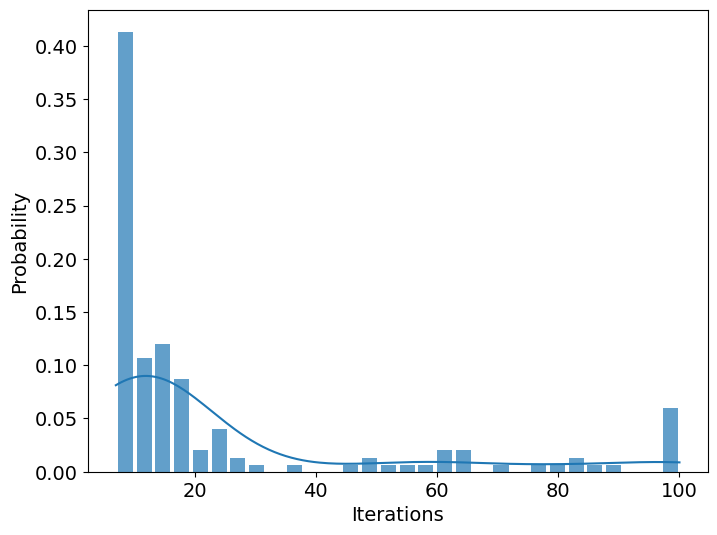

In [3]:
# Plot kde, tweak plotting defaults
kwargs = {'kde': True,
          'bins': 30,
          'line_kws': {'linewidth': 1.5},
          'shrink': 0.8,
          'edgecolor': 'none',
          'linewidth': 0.5,
          'alpha': 0.7,
          }

sns.histplot(iteration_counts, stat='probability', **kwargs)
plt.xlabel("Iterations")
plt.savefig("histogram.pdf")

Part (b)

In [4]:
heights_file = np.load("heights.npz")
height25 = heights_file['height_25']
height50 = heights_file['height_50']
height75 = heights_file['height_75']
height100 = heights_file['height_100']
X = heights_file['X']
Y = heights_file['Y']

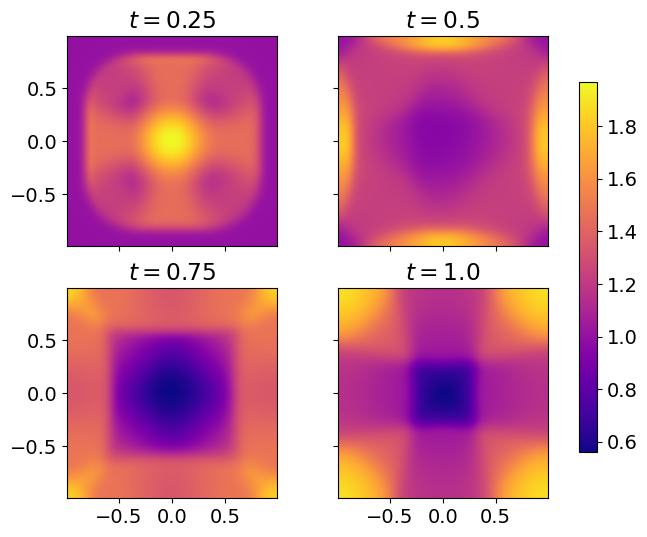

In [5]:
# Four subplots

params = {'figure.figsize':[8,6]}
mpl.rcParams.update(params)

fig, ax = plt.subplots(nrows=2, ncols=2, sharey=True, sharex=True)

xmin = np.min(X)
xmax = np.max(X)
ymin = np.min(Y)
ymax = np.max(Y)

mins = [np.min(data) for data in [height25, height50, height75, height100]]
maxes = [np.max(data) for data in [height25, height50, height75, height100]]

data_min = np.min(mins)
data_max = np.max(maxes)

cmap = 'plasma'
extents = [xmin, xmax, ymin, ymax]

kwargs = {'cmap': cmap, 'vmin': data_min, 'vmax': data_max, 'extent': extents, 'interpolation': 'bilinear'}

ax[0][0].imshow(height25, **kwargs)
ax[0][1].imshow(height50, **kwargs)
ax[1][0].imshow(height75, **kwargs)
tmp = ax[1][1].imshow(height100, **kwargs)

ax[0][0].set_title('$t=0.25$')
ax[0][1].set_title('$t=0.5$')
ax[1][0].set_title('$t=0.75$')
ax[1][1].set_title('$t=1.0$')


fig.colorbar(tmp, ax=ax[:, :], shrink=0.8)

plt.savefig('heatmaps.pdf')

In [6]:
RR_file = np.load("RR_data.npz")

RR5000_nref4 = RR_file['RR5000_nref4']
RR5000_nref5 = RR_file['RR5000_nref5']
RR5000_nref6 = RR_file['RR5000_nref6']
RR5000_nref7 = RR_file['RR5000_nref7']

RR10000_nref4 = RR_file['RR10000_nref4']
RR10000_nref5 = RR_file['RR10000_nref5']
RR10000_nref6 = RR_file['RR10000_nref6']
RR10000_nref7 = RR_file['RR10000_nref7']

RR20000_nref4 = RR_file['RR20000_nref4']
RR20000_nref5 = RR_file['RR20000_nref5']
RR20000_nref6 = RR_file['RR20000_nref6']
RR20000_nref7 = RR_file['RR20000_nref7']

times_nref4 = RR_file['times_nref4']
times_nref5 = RR_file['times_nref5']
times_nref6 = RR_file['times_nref6']
times_nref7 = RR_file['times_nref7']


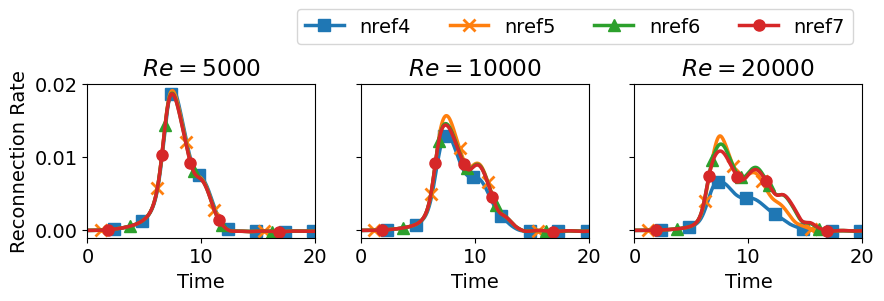

In [7]:
params = {'figure.figsize':[10,2], 'lines.markersize':8}
mpl.rcParams.update(params)


# three subplots
fig, ax = plt.subplots(nrows=1, ncols=3, sharey=True)

kwargs4 = {'marker':'s', 'markevery':(100,100)}
kwargs5 = {'marker':'x', 'markevery':[100,500,700,900,1250], 'markeredgewidth':2}
kwargs6 = {'marker':'^', 'markevery':[600,1100,1500,1900,2600]}
kwargs7 = {'marker':'o', 'markevery':[600,2100,2900,3700,5400]}

axes = ax[0] # Left axes
l1 = axes.plot(times_nref4,RR5000_nref4,**kwargs4)[0]
l2 = axes.plot(times_nref5,RR5000_nref5,**kwargs5)[0]
l3 = axes.plot(times_nref6,RR5000_nref6,**kwargs6)[0]
l4 = axes.plot(times_nref7,RR5000_nref7,**kwargs7)[0]
axes.set_ylim(-0.001,0.02)
axes.set_xlim(0,20)
axes.set_title(r'$Re = 5000$')

axes = ax[1] # Middle axes
axes.plot(times_nref4,RR10000_nref4, **kwargs4)
axes.plot(times_nref5,RR10000_nref5, **kwargs5)
axes.plot(times_nref6,RR10000_nref6, **kwargs6)
axes.plot(times_nref7,RR10000_nref7, **kwargs7)
axes.set_xlim(0,20)
axes.set_title(r'$Re = 10000$')

axes = ax[2] # Right axes
axes.plot(times_nref4,RR20000_nref4, **kwargs4)
axes.plot(times_nref5,RR20000_nref5, **kwargs5)
axes.plot(times_nref6,RR20000_nref6, **kwargs6)
axes.plot(times_nref7,RR20000_nref7, **kwargs7)
axes.set_xlim(0,20)
axes.set_title(r'$Re = 20000$')

ax[0].set_xlabel('Time')
ax[1].set_xlabel('Time')
ax[2].set_xlabel('Time')
ax[0].set_ylabel('Reconnection Rate')

fig.legend((l1,l2,l3,l4),("nref4","nref5","nref6","nref7"),ncol=4,bbox_to_anchor=(0.9,1.3))
plt.savefig('linegraphs.pdf')